# Mrk 421 — STA/LTA Flare & Dip Detection
FACT nightly data, 2015–2019. Bidirectional detection (brightenings and dips).

In [ ]:
#Gian :D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(
    "../../data/FACT_preliminary_421_nightly_150101_191231_katha.dat",
    sep="\t",
    skiprows=4,
    names=[
        "MJDstart", "MJDstop",
        "flux_ph_cm2_s", "flux_err_ph_cm2_s",
        "flux_CU", "flux_err_CU",
        "ontime",
        "flag1", "flag2", "flag3", "flag4",
    ]
)

# ── Clean: drop non-numeric header row ───────────────────────────────────────
mask_bad = pd.to_numeric(df["flux_ph_cm2_s"], errors="coerce").isna()
df = df[~mask_bad].copy()
for col in ["MJDstart", "MJDstop", "flux_ph_cm2_s", "flux_err_ph_cm2_s",
            "flux_CU", "flux_err_CU"]:
    df[col] = pd.to_numeric(df[col])

# ── Time axis ────────────────────────────────────────────────────────────────
# MJD midpoint of each nightly observation
df["MJD"] = (df["MJDstart"] + df["MJDstop"]) / 2
# Convert to DatetimeIndex so pandas rolling('ND') works on physical time
df["Fecha"] = pd.to_datetime(df["MJD"] - 40587.0, unit="D")
df.set_index("Fecha", inplace=True)
df.sort_index(inplace=True)

print(f"Observations loaded: {len(df)}")
print(f"Coverage: {df.index[0].date()} → {df.index[-1].date()}")

Observations loaded: 601
Coverage: 2015-01-15 → 2019-06-27


In [ ]:
def compute_sta_lta_zscore(df, sta_window, lta_window, min_lta_obs=5):
    """Compute a robust STA/LTA Z-score for each nightly observation.

    The Z-score measures how many robust standard deviations the short-term
    average (STA) lies above or below the long-term median background (LTA).
    Positive values flag brightenings; negative values flag dips.

    The denominator combines:
      - Instrumental measurement uncertainty on the STA mean.
      - Intrinsic source scatter estimated via MAD over the LTA window.
        MAD is used instead of variance to prevent bright flares or deep dips
        from inflating the denominator and masking themselves.

    Args:
        df (pd.DataFrame): DataFrame with a DatetimeIndex and columns
            ``flux_ph_cm2_s`` and ``flux_err_ph_cm2_s``.
        sta_window (str): Short-window size as a pandas offset, e.g. ``'3D'``.
        lta_window (str): Long-window size as a pandas offset, e.g. ``'21D'``.
            Rule of thumb: LTA ~ 7–10× STA.
        min_lta_obs (int): Minimum number of observations required inside the
            LTA window to compute a background estimate. Rows with fewer
            observations yield NaN. Default: 5.

    Returns:
        pd.DataFrame: Copy of ``df`` with additional columns:
            ``N_STA``, ``N_LTA``, ``STA_mean``, ``LTA_median``,
            ``sigma_meas``, ``sigma_intrinsic``, ``sigma_total``,
            ``Z_score``.
    """
    out  = df.copy()
    flux = out["flux_ph_cm2_s"]
    err  = out["flux_err_ph_cm2_s"]

    # ── Observation counts inside each window ─────────────────────────────
    # A '21D' window that falls in a cloudy stretch may contain only 2 nights;
    # tracking N makes the uncertainty propagation honest.
    out["N_STA"] = flux.rolling(sta_window, min_periods=1).count()
    out["N_LTA"] = flux.rolling(lta_window, min_periods=min_lta_obs).count()

    # ── STA: mean and its measurement uncertainty ─────────────────────────
    # σ(mean) = sqrt( mean(σ_i²) / N )  — standard error of the mean
    out["STA_mean"]  = flux.rolling(sta_window, min_periods=1).mean()
    out["sigma_meas"] = np.sqrt(
        (err ** 2).rolling(sta_window, min_periods=1).mean() / out["N_STA"]
    )

    # ── LTA: robust background (median) ──────────────────────────────────
    # Median is resistant to masking: a single bright flare does not
    # shift the median of 20 observations appreciably.
    out["LTA_median"] = flux.rolling(lta_window, min_periods=min_lta_obs).median()

    # ── MAD: robust intrinsic scatter ────────────────────────────────────
    # Step 1 – absolute deviation of each point from the rolling median.
    #          Because the median is look-back only, this operation is causal.
    abs_dev = (flux - out["LTA_median"]).abs()
    # Step 2 – median of those absolute deviations over the LTA window.
    rolling_mad = abs_dev.rolling(lta_window, min_periods=min_lta_obs).median()
    # Step 3 – convert MAD to σ-equivalent (factor 1.4826 assumes normality
    #          but the estimator is robust regardless of the distribution).
    out["sigma_intrinsic"] = 1.4826 * rolling_mad

    # ── Total denominator ─────────────────────────────────────────────────
    out["sigma_total"] = np.sqrt(out["sigma_meas"] ** 2
                                 + out["sigma_intrinsic"] ** 2)

    # ── Z-score ───────────────────────────────────────────────────────────
    # Positive → STA above LTA  (brightening / flare)
    # Negative → STA below LTA  (dip / sudden fading)
    out["Z_score"] = (out["STA_mean"] - out["LTA_median"]) / (
        out["sigma_total"] + 1e-30
    )

    return out

In [ ]:
# ── Filter bank ──────────────────────────────────────────────────────────────
# Each scale targets a different event duration.
# LTA ~ 7–10× STA follows the seismology convention.
SCALES = [
    ("1D",  "10D",  "Fast   (1d / 10d)"),
    ("3D",  "21D",  "Medium (3d / 21d)"),
    ("7D",  "42D",  "Slow   (7d / 42d)"),
]

# Empirically calibrated against the 2015–2016 quiescent period.
# The 3d/21d filter yields p99.7 = 3.05σ ≈ 3.00σ Gaussian.
THRESHOLD = 3.0

results = {}
for sta_w, lta_w, label in SCALES:
    results[label] = compute_sta_lta_zscore(df, sta_w, lta_w)
    res = results[label]
    n_bright = (res["Z_score"] >=  THRESHOLD).sum()
    n_dip    = (res["Z_score"] <= -THRESHOLD).sum()
    print(f"{label:25s}  brightenings: {n_bright:3d}   dips: {n_dip:3d}")

Fast   (1d / 10d)          brightenings:   7   dips:   1
Medium (3d / 21d)          brightenings:   9   dips:   0
Slow   (7d / 42d)          brightenings:   4   dips:   0


In [ ]:
# ── Empirical calibration ─────────────────────────────────────────────────────
# Quiescent control region: historically low state of Mrk 421 (Acciari+2020)
QUIESCENT_START = "2015-01-01"
QUIESCENT_END   = "2016-07-01"

print(f"Quiescent period: {QUIESCENT_START} → {QUIESCENT_END}")
print(f"{'Scale':25s}  {'p99.7 empirical':>18s}  {'p99.7 Gaussian':>16s}")
print("-" * 65)
for sta_w, lta_w, label in SCALES:
    res  = results[label]
    mask = (res.index >= QUIESCENT_START) & (res.index <= QUIESCENT_END)
    z_q  = res.loc[mask, "Z_score"].dropna()
    p997 = z_q.quantile(0.997)
    print(f"{label:25s}  {p997:>18.2f}σ  {'3.00':>16s}σ")

Quiescent period: 2015-01-01 → 2016-07-01
Scale                         p99.7 empirical    p99.7 Gaussian
-----------------------------------------------------------------
Fast   (1d / 10d)                        4.89σ              3.00σ
Medium (3d / 21d)                        3.05σ              3.00σ
Slow   (7d / 42d)                        2.71σ              3.00σ


In [ ]:
import numpy
import astropy
print(f"NumPy version: {numpy.__version__}")
print(f"Astropy version: {astropy.__version__}")

NumPy version: 2.4.4
Astropy version: 7.2.0


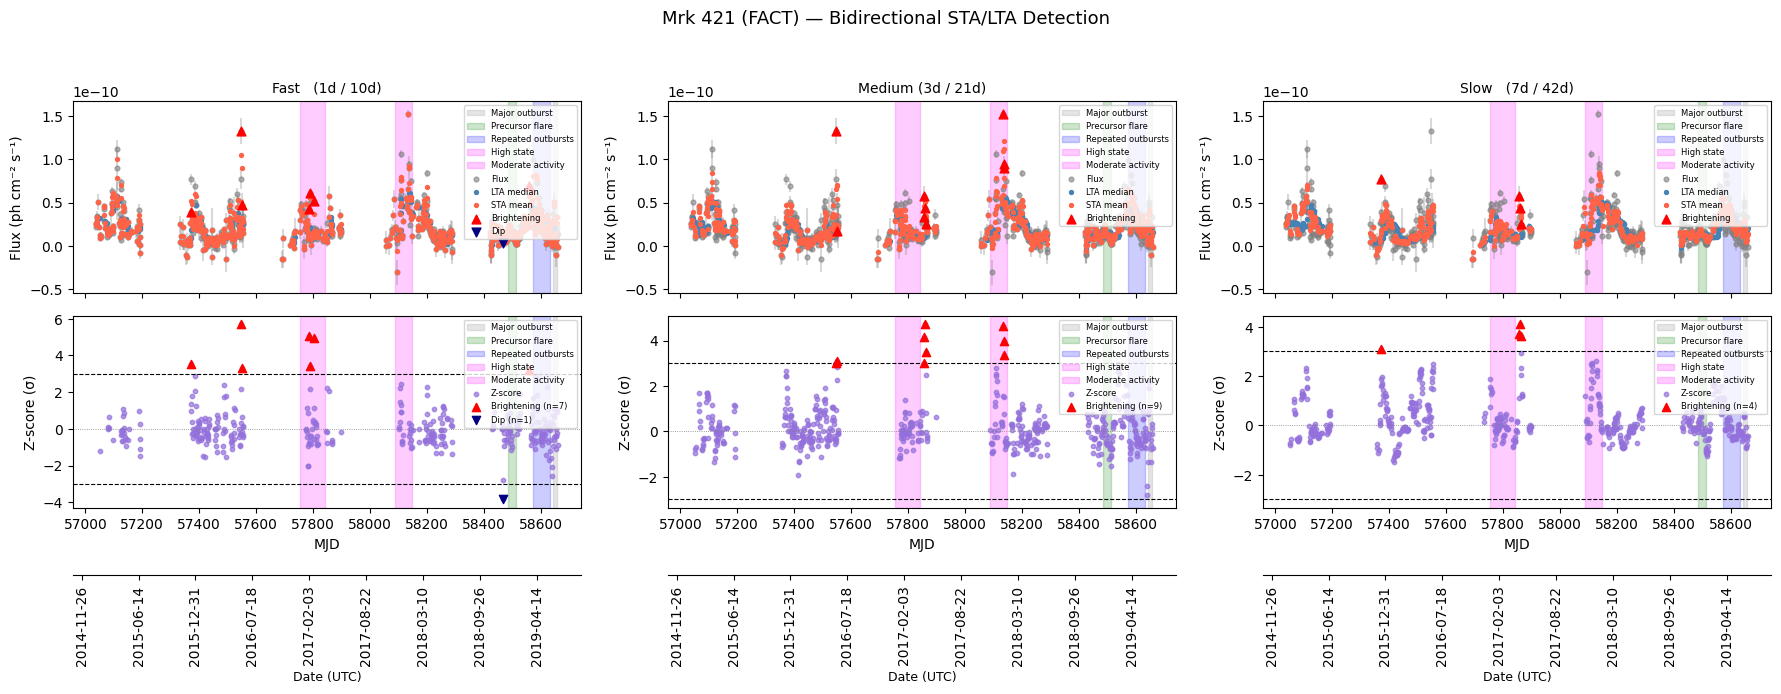


Threshold: ±3.0σ
Scale                        Brightenings    Dips    Total
----------------------------------------------------------
Fast   (1d / 10d)                       7       1        8
Medium (3d / 21d)                       9       0        9
Slow   (7d / 42d)                       4       0        4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib.dates as mdates

# ── Define the shaded region in MJD ──────────────────────────────────────────
t_start_mjd = Time("2019-06-09").mjd
t_end_mjd   = Time("2019-06-25").mjd

# ── Define the shaded region in MJD ──────────────────────────────────────────
t_start_mjd_2 = Time("2019-01-01").mjd
t_end_mjd_2   = Time("2019-01-31").mjd

# ── Define the shaded region in MJD ──────────────────────────────────────────
t_start_mjd_3 = Time("2019-04-01").mjd
t_end_mjd_3   = Time("2019-05-31").mjd

# ── Define the shaded region in MJD ──────────────────────────────────────────
t_start_mjd_4 = Time("2017-12-01").mjd
t_end_mjd_4   = Time("2018-01-31").mjd

# ── Define the shaded region in MJD ──────────────────────────────────────────
t_start_mjd_5 = Time("2017-01-01").mjd
t_end_mjd_5   = Time("2017-03-31").mjd

# ── Bidirectional detection & visualisation ─────────────────────────────────── 
fig, axes = plt.subplots( 
    nrows=2, ncols=len(SCALES), 
    figsize=(6 * len(SCALES), 8), 
    sharex=True,#dpi=500
) 

for col_idx, (sta_w, lta_w, label) in enumerate(SCALES): 
    res = results[label] 

    # ── Bidirectional detection ─────────────────────────────────────────── 
    bright = res[res["Z_score"] >=  THRESHOLD].copy() 
    dip    = res[res["Z_score"] <= -THRESHOLD].copy() 

    ax_lc = axes[0, col_idx] 
    ax_z  = axes[1, col_idx] 

    # ── Shaded region for specific dates (applied to both rows) ───────────
    for ax in [ax_lc, ax_z]:
        ax.axvspan(t_start_mjd, t_end_mjd, color="gray", alpha=0.2, 
                   label="Major outburst", zorder=0)
        ax.axvspan(t_start_mjd_2, t_end_mjd_2, color="green", alpha=0.2, 
                   label="Precursor flare", zorder=0)
        ax.axvspan(t_start_mjd_3, t_end_mjd_3, color="blue", alpha=0.2, 
                   label="Repeated outbursts", zorder=0)
        ax.axvspan(t_start_mjd_4, t_end_mjd_4, color="magenta", alpha=0.2, 
                   label="High state", zorder=0)
        ax.axvspan(t_start_mjd_5, t_end_mjd_5, color="magenta", alpha=0.2, 
                   label="Moderate activity", zorder=0)


    # ── Light curve panel ───────────────────────────────────────────────── 
    ax_lc.errorbar( 
        res["MJD"], res["flux_ph_cm2_s"], 
        yerr=res["flux_err_ph_cm2_s"], 
        fmt="none", ecolor="gray", alpha=0.3, zorder=1, 
    ) 
    ax_lc.scatter(res["MJD"], res["flux_ph_cm2_s"], 
                  color="gray", alpha=0.6, s=12, label="Flux", zorder=2) 
    ax_lc.scatter(res["MJD"], res["LTA_median"], 
                  color="steelblue", s=8, label="LTA median", zorder=3) 
    ax_lc.scatter(res["MJD"], res["STA_mean"], 
                  color="tomato", s=8, label="STA mean", zorder=4) 
    
    # Mark detected events on light curve 
    if not bright.empty: 
        ax_lc.scatter(bright["MJD"], bright["flux_ph_cm2_s"], 
                      color="red", s=40, marker="^", zorder=5, 
                      label="Brightening") 
    if not dip.empty: 
        ax_lc.scatter(dip["MJD"], dip["flux_ph_cm2_s"], 
                      color="navy", s=40, marker="v", zorder=5, 
                      label="Dip") 
    ax_lc.set_ylabel("Flux (ph cm⁻² s⁻¹)") 
    ax_lc.set_title(label, fontsize=10) 
    ax_lc.legend(fontsize=6,loc= "upper right") 

    # ── Z-score panel ──────────────────────────────────────────────────── 
    ax_z.axhline( THRESHOLD, color="black", linestyle="--", linewidth=0.8) 
    ax_z.axhline(-THRESHOLD, color="black", linestyle="--", linewidth=0.8) 
    ax_z.axhline(0, color="gray", linestyle=":", linewidth=0.6) 
    ax_z.scatter(res["MJD"], res["Z_score"], 
                 color="mediumpurple", s=10, alpha=0.7, label="Z-score") 
    
    if not bright.empty: 
        ax_z.scatter(bright["MJD"], bright["Z_score"], 
                     color="red", s=35, zorder=5, marker="^", 
                     label=f"Brightening (n={len(bright)})") 
    if not dip.empty: 
        ax_z.scatter(dip["MJD"], dip["Z_score"], 
                     color="navy", s=35, zorder=5, marker="v", 
                     label=f"Dip (n={len(dip)})") 
    ax_z.set_xlabel("MJD") 
    ax_z.set_ylabel("Z-score (σ)") 
    ax_z.legend(fontsize=6, loc= "upper right")
 

    # ── Secondary Date Axis ───────────────────────────────────────────────
    def mjd_to_date(mjd_val):
        mjd_val = np.asanyarray(mjd_val)
        if mjd_val.size == 0:
            return mjd_val
        t = Time(mjd_val, format='mjd')
        return mdates.date2num(t.to_datetime())

    def date_to_mjd(date_num):
        date_num = np.asanyarray(date_num)
        if date_num.size == 0:
            return date_num
        try:
            t = Time(mdates.num2date(date_num))
            return t.mjd
        except Exception:
            return np.full_like(date_num, np.nan)

    secax = ax_z.secondary_xaxis(-0.35, functions=(mjd_to_date, date_to_mjd))
    secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    secax.set_xlabel("Date (UTC)", fontsize=9)
    plt.setp(secax.get_xticklabels(), rotation=90, ha='center')



plt.suptitle("Mrk 421 (FACT) — Bidirectional STA/LTA Detection", 
             fontsize=13, y=0.98) 
plt.tight_layout(rect=(0, 0.08, 1, 0.95)) 
plt.show() 

# ── Detection summary ───────────────────────────────────────────────────── 
print(f"\nThreshold: ±{THRESHOLD}σ") 
print(f"{'Scale':25s}  {'Brightenings':>14s}  {'Dips':>6s}  {'Total':>7s}") 
print("-" * 58) 
for sta_w, lta_w, label in SCALES: 
    res    = results[label] 
    bright = res[res["Z_score"] >=  THRESHOLD] 
    dip    = res[res["Z_score"] <= -THRESHOLD] 
    total  = len(bright) + len(dip) 
    print(f"{label:25s}  {len(bright):>14d}  {len(dip):>6d}  {total:>7d}")

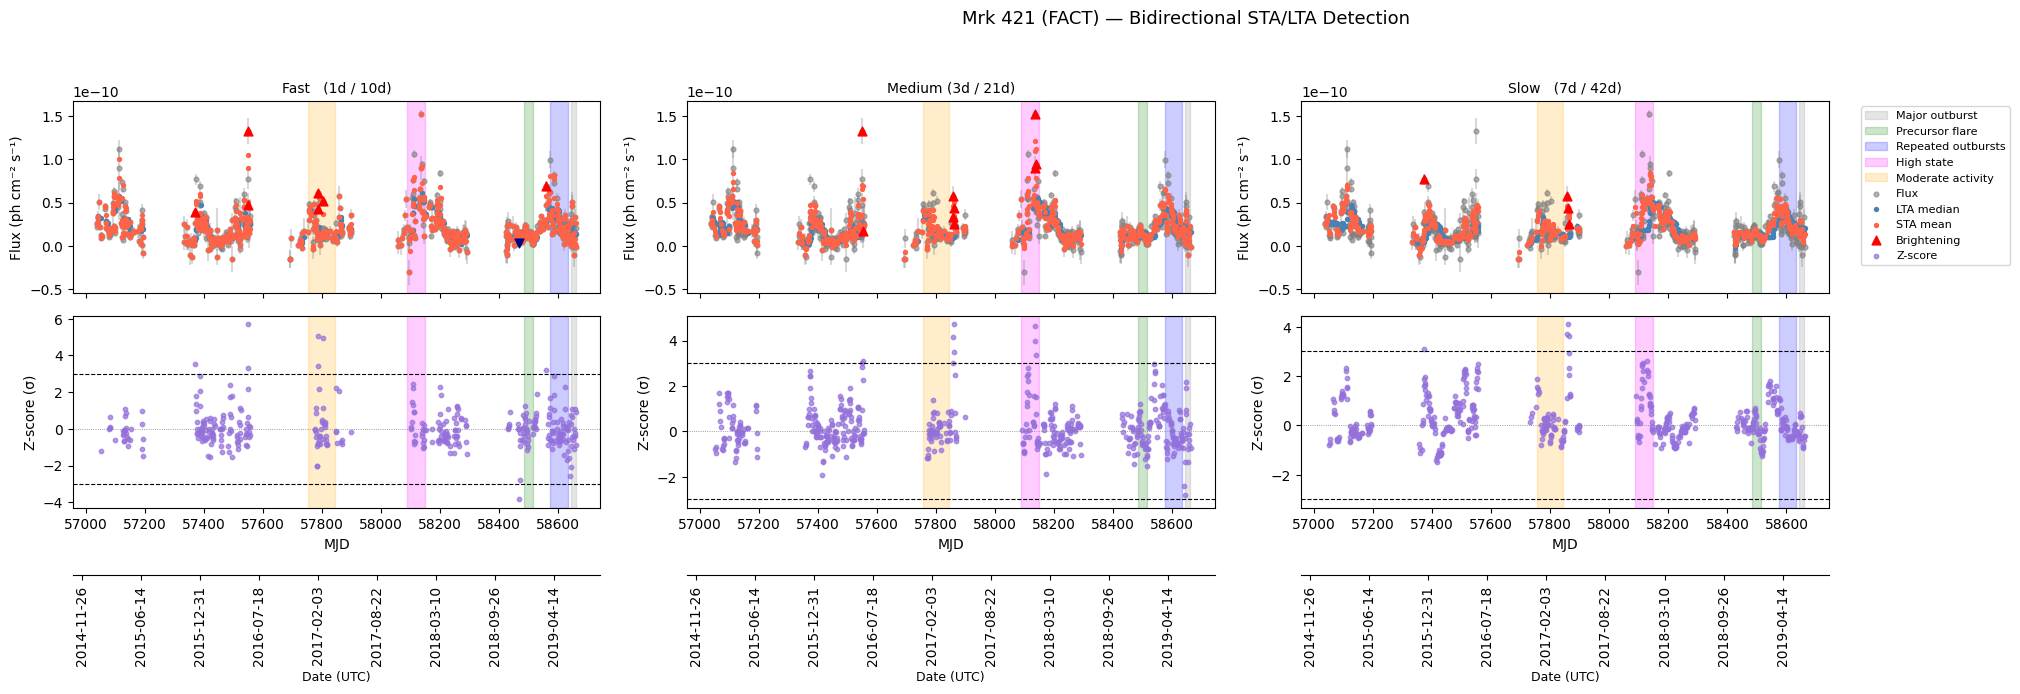


Threshold: ±3.0σ
Scale                        Brightenings    Dips    Total
----------------------------------------------------------
Fast   (1d / 10d)                       7       1        8
Medium (3d / 21d)                       9       0        9
Slow   (7d / 42d)                       4       0        4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib.dates as mdates

# -- Define shaded regions --
t_regions = [
    (Time("2019-06-09").mjd, Time("2019-06-25").mjd, "gray", "Major outburst"),
    (Time("2019-01-01").mjd, Time("2019-01-31").mjd, "green", "Precursor flare"),
    (Time("2019-04-01").mjd, Time("2019-05-31").mjd, "blue", "Repeated outbursts"),
    (Time("2017-12-01").mjd, Time("2018-01-31").mjd, "magenta", "High state"),
    (Time("2017-01-01").mjd, Time("2017-03-31").mjd, "orange", "Moderate activity"),
]

fig, axes = plt.subplots( 
    nrows=2, ncols=len(SCALES), 
    figsize=(6 * len(SCALES) + 6, 8), # Added width for the legend area
    sharex=True
) 

# Ensure axes is 2D even if len(SCALES) == 1
if len(SCALES) == 1:
    axes = axes.reshape(2, 1)

for col_idx, (sta_w, lta_w, label) in enumerate(SCALES): 
    res = results[label] 
    bright = res[res["Z_score"] >=  THRESHOLD].copy() 
    dip    = res[res["Z_score"] <= -THRESHOLD].copy() 

    ax_lc = axes[0, col_idx] 
    ax_z  = axes[1, col_idx] 

    # -- Apply Shaded regions --
    for ax in [ax_lc, ax_z]:
        for start, end, col, lab in t_regions:
            ax.axvspan(start, end, color=col, alpha=0.2, label=lab, zorder=0)

    # -- Light curve panel -- 
    ax_lc.errorbar(res["MJD"], res["flux_ph_cm2_s"], yerr=res["flux_err_ph_cm2_s"], 
                   fmt="none", ecolor="gray", alpha=0.3, zorder=1) 
    ax_lc.scatter(res["MJD"], res["flux_ph_cm2_s"], color="gray", alpha=0.6, s=12, label="Flux", zorder=2) 
    ax_lc.scatter(res["MJD"], res["LTA_median"], color="steelblue", s=8, label="LTA median", zorder=3) 
    ax_lc.scatter(res["MJD"], res["STA_mean"], color="tomato", s=8, label="STA mean", zorder=4) 
    
    if not bright.empty: 
        ax_lc.scatter(bright["MJD"], bright["flux_ph_cm2_s"], color="red", s=40, marker="^", zorder=5, label="Brightening") 
    if not dip.empty: 
        ax_lc.scatter(dip["MJD"], dip["flux_ph_cm2_s"], color="navy", s=40, marker="v", zorder=5, label="Dip") 
    
    ax_lc.set_ylabel("Flux (ph cm⁻² s⁻¹)") 
    ax_lc.set_title(label, fontsize=10) 

    # -- Z-score panel -- 
    ax_z.axhline(THRESHOLD, color="black", linestyle="--", linewidth=0.8) 
    ax_z.axhline(-THRESHOLD, color="black", linestyle="--", linewidth=0.8) 
    ax_z.axhline(0, color="gray", linestyle=":", linewidth=0.6) 
    ax_z.scatter(res["MJD"], res["Z_score"], color="mediumpurple", s=10, alpha=0.7, label="Z-score") 
    
    ax_z.set_xlabel("MJD") 
    ax_z.set_ylabel("Z-score (σ)") 



# ── Updated Secondary Date Axis Functions ───────────────────────────
    def mjd_to_date(mjd_val):
        mjd_val = np.asanyarray(mjd_val)
        if mjd_val.size == 0:
            return mjd_val
        t = Time(mjd_val, format='mjd')
        return mdates.date2num(t.to_datetime())

    def date_to_mjd(date_num):
        date_num = np.asanyarray(date_num)
        if date_num.size == 0:
            return date_num
        # Matplotlib uses a specific floating point for dates; 
        # mdates.num2date handles the conversion to datetime
        dt = mdates.num2date(date_num)
        t = Time(dt)
        return t.mjd

    secax = ax_z.secondary_xaxis(-0.35, functions=(mjd_to_date, date_to_mjd))
    secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    secax.set_xlabel("Date (UTC)", fontsize=9)
    plt.setp(secax.get_xticklabels(), rotation=90, ha='center')

# -- Single Global Legend --
# Get handles from the last axes and remove duplicates
handles, labels = ax_lc.get_legend_handles_labels()
z_h, z_l = ax_z.get_legend_handles_labels()
all_h, all_l = handles + z_h, labels + z_l
by_label = dict(zip(all_l, all_h))

# Place legend in the right-side padding of the last column
axes[0, -1].legend(by_label.values(), by_label.keys(), 
                   loc='upper left', bbox_to_anchor=(1.05, 1), 
                   fontsize=8, frameon=True)

plt.suptitle("Mrk 421 (FACT) — Bidirectional STA/LTA Detection", fontsize=13, y=0.98) 
plt.tight_layout(rect=(0, 0.08, 0.85, 0.95)) # rect left, bottom, right, top
plt.show()

# -- Detection summary -- 
print(f"\nThreshold: ±{THRESHOLD}σ") 
print(f"{'Scale':25s}  {'Brightenings':>14s}  {'Dips':>6s}  {'Total':>7s}") 
print("-" * 58) 
for sta_w, lta_w, label in SCALES: 
    res = results[label] 
    b, d = len(res[res["Z_score"] >= THRESHOLD]), len(res[res["Z_score"] <= -THRESHOLD]) 
    print(f"{label:25s}  {b:>14d}  {d:>6d}  {b+d:>7d}")

/var/folders/74/0zssb6h97glb_0klc2951pqc0000gn/T/ipykernel_13154/4125247533.py:49: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(start, end, color=col, alpha=0.10,


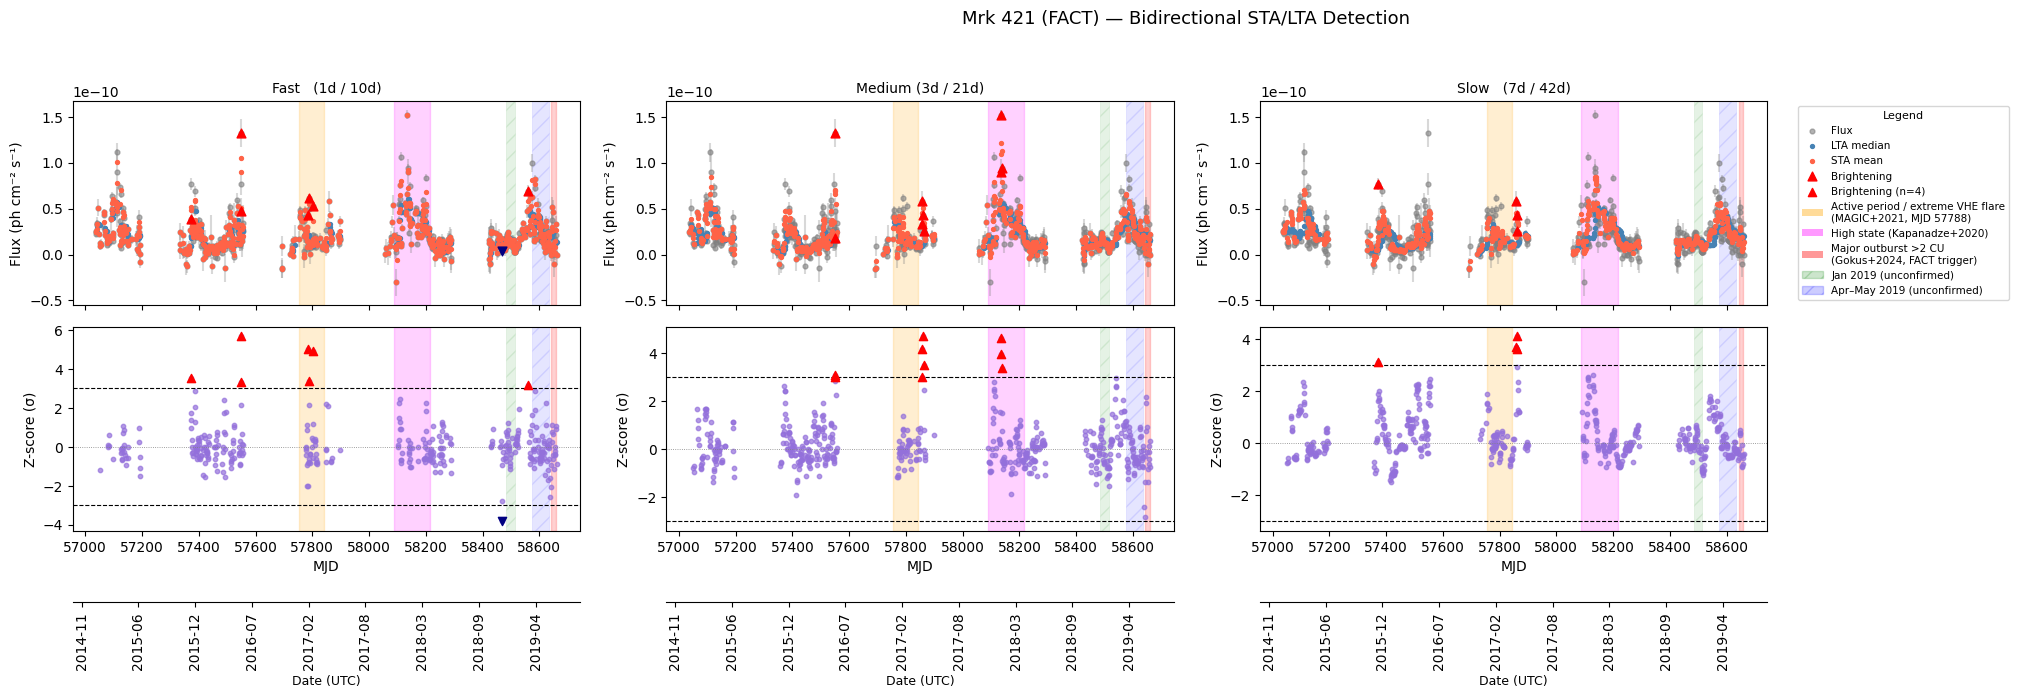


Threshold: ±3.0σ
Scale                        Brightenings    Dips    Total
----------------------------------------------------------
Fast   (1d / 10d)                       7       1        8
Medium (3d / 21d)                       9       0        9
Slow   (7d / 42d)                       4       0        4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ── Shaded regions: confirmed vs unconfirmed ──────────────────────────────────
# Solid alpha for literature-confirmed periods, lighter + hatched for unconfirmed.
t_regions_confirmed = [
    (Time("2017-01-01").mjd, Time("2017-03-31").mjd,
     "orange", "Active period / extreme VHE flare\n(MAGIC+2021, MJD 57788)"),
    (Time("2017-12-01").mjd, Time("2018-04-08").mjd,
     "magenta", "High state (Kapanadze+2020)"),
    (Time("2019-06-09").mjd, Time("2019-06-25").mjd,
     "red", "Major outburst >2 CU\n(Gokus+2024, FACT trigger)"),
]

t_regions_unconfirmed = [
    (Time("2019-01-01").mjd, Time("2019-01-31").mjd,
     "green", "Jan 2019 (unconfirmed)"),
    (Time("2019-04-01").mjd, Time("2019-05-31").mjd,
     "blue", "Apr–May 2019 (unconfirmed)"),
]

fig, axes = plt.subplots(
    nrows=2, ncols=len(SCALES),
    figsize=(6 * len(SCALES) + 6, 8),
    sharex=True
)

if len(SCALES) == 1:
    axes = axes.reshape(2, 1)

for col_idx, (sta_w, lta_w, label) in enumerate(SCALES):
    res    = results[label]
    bright = res[res["Z_score"] >=  THRESHOLD].copy()
    dip    = res[res["Z_score"] <= -THRESHOLD].copy()

    ax_lc = axes[0, col_idx]
    ax_z  = axes[1, col_idx]

    for ax in [ax_lc, ax_z]:
        # Literature-confirmed periods — solid fill
        for start, end, col, _ in t_regions_confirmed:
            ax.axvspan(start, end, color=col, alpha=0.18, zorder=0)
        # Unconfirmed periods — hatched to signal lower epistemic status
        for start, end, col, _ in t_regions_unconfirmed:

            ax.axvspan(start, end, color=col, alpha=0.10,
                       hatch="//", edgecolor=col, linewidth=0.5, zorder=0)

    # ── Light curve panel ─────────────────────────────────────────────────
    ax_lc.errorbar(res["MJD"], res["flux_ph_cm2_s"],
                   yerr=res["flux_err_ph_cm2_s"],
                   fmt="none", ecolor="gray", alpha=0.3, zorder=1)
    ax_lc.scatter(res["MJD"], res["flux_ph_cm2_s"],
                  color="gray", alpha=0.6, s=12, label="Flux", zorder=2)
    ax_lc.scatter(res["MJD"], res["LTA_median"],
                  color="steelblue", s=8, label="LTA median", zorder=3)
    ax_lc.scatter(res["MJD"], res["STA_mean"],
                  color="tomato", s=8, label="STA mean", zorder=4)
    if not bright.empty:
        ax_lc.scatter(bright["MJD"], bright["flux_ph_cm2_s"],
                      color="red", s=40, marker="^", zorder=5, label="Brightening")
    if not dip.empty:
        ax_lc.scatter(dip["MJD"], dip["flux_ph_cm2_s"],
                      color="navy", s=40, marker="v", zorder=5, label="Dip")
    ax_lc.set_ylabel("Flux (ph cm⁻² s⁻¹)")
    ax_lc.set_title(label, fontsize=10)

    # ── Z-score panel ─────────────────────────────────────────────────────
    ax_z.axhline( THRESHOLD, color="black", linestyle="--", linewidth=0.8)
    ax_z.axhline(-THRESHOLD, color="black", linestyle="--", linewidth=0.8)
    ax_z.axhline(0, color="gray", linestyle=":", linewidth=0.6)
    ax_z.scatter(res["MJD"], res["Z_score"],
                 color="mediumpurple", s=10, alpha=0.7)
    if not bright.empty:
        ax_z.scatter(bright["MJD"], bright["Z_score"],
                     color="red", s=35, marker="^", zorder=5,
                     label=f"Brightening (n={len(bright)})")
    if not dip.empty:
        ax_z.scatter(dip["MJD"], dip["Z_score"],
                     color="navy", s=35, marker="v", zorder=5,
                     label=f"Dip (n={len(dip)})")
    ax_z.set_xlabel("MJD")
    ax_z.set_ylabel("Z-score (σ)")

# ── Secondary date axis (all columns) ────────────────────────────────
    def mjd_to_date(mjd_val):
        """Convert MJD array to matplotlib date numbers."""
        mjd_val = np.asanyarray(mjd_val)
        if mjd_val.size == 0:
            return mjd_val
        return mdates.date2num(Time(mjd_val, format="mjd").to_datetime())

    def date_to_mjd(date_num):
        """Convert matplotlib date numbers to MJD."""
        date_num = np.asanyarray(date_num)
        if date_num.size == 0:
            return date_num
        return Time(mdates.num2date(date_num)).mjd

    secax = ax_z.secondary_xaxis(
        -0.35, functions=(mjd_to_date, date_to_mjd)
    )
    secax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    secax.set_xlabel("Date (UTC)", fontsize=9)
    plt.setp(secax.get_xticklabels(), rotation=90, ha="center")

# ── Global legend ─────────────────────────────────────────────────────────────
# Data elements from last panel
handles, labels_h = axes[0, -1].get_legend_handles_labels()
z_h, z_l = axes[1, -1].get_legend_handles_labels()
combined = dict(zip(labels_h + z_l, handles + z_h))

# Activity period patches — confirmed
for start, end, col, lab in t_regions_confirmed:
    combined[lab] = Patch(facecolor=col, alpha=0.4, label=lab)

# Activity period patches — unconfirmed (hatched)
for start, end, col, lab in t_regions_unconfirmed:
    combined[lab] = Patch(facecolor=col, alpha=0.2,
                          hatch="//", edgecolor=col, label=lab)

axes[0, -1].legend(
    combined.values(), combined.keys(),
    loc="upper left", bbox_to_anchor=(1.05, 1),
    fontsize=7.5, frameon=True, title="Legend", title_fontsize=8
)

plt.suptitle("Mrk 421 (FACT) — Bidirectional STA/LTA Detection", fontsize=13, y=0.98)
plt.tight_layout(rect=(0, 0.08, 0.85, 0.95))
plt.show()

# ── Detection summary ─────────────────────────────────────────────────────────
print(f"\nThreshold: ±{THRESHOLD}σ")
print(f"{'Scale':25s}  {'Brightenings':>14s}  {'Dips':>6s}  {'Total':>7s}")
print("-" * 58)
for sta_w, lta_w, label in SCALES:
    res = results[label]
    b = len(res[res["Z_score"] >=  THRESHOLD])
    d = len(res[res["Z_score"] <= -THRESHOLD])
    print(f"{label:25s}  {b:>14d}  {d:>6d}  {b+d:>7d}")

| Date(s)                    | Activity Level                        | Instruments              | Notes                                                                                      | Status      |
|:---------------------------|:--------------------------------------|:-------------------------|:-------------------------------------------------------------------------------------------|:------------|
| Jan – Mar 2017             | Active period incl. extreme VHE flare | FACT, MAGIC, NuSTAR      | MJD 57788 (Feb 4): factor-10 TeV increase, orphan-like, two-zone leptonic model required   | Confirmed   |
| Dec 2017 – Apr 2018        | High state                            | Swift XRT/BAT, FACT      | Active epoch MJD 58090–58216; complex X-ray/TeV variability (Kapanadze+2020)               | Confirmed   |
| Jan 2019                   | Unknown                               | —                        | Not found in Arbet-Engels+2021 or any indexed publication; possibly internal quick-look    | Unconfirmed |
| Apr – May 2019             | Unknown                               | —                        | No peer-reviewed reference found for this specific period                                  | Unconfirmed |
| Jun 9–25, 2019             | Major outburst                        | FACT (trigger), XMM, INTEGRAL | >2 CU on Jun 9; brightest XMM-Newton state ever recorded (Gokus+2024)               | Confirmed   |
